In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, chi2_contingency
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [2]:
DATA_PATH = "datasets/"

customers = pd.read_csv(DATA_PATH + "olist_customers_dataset.csv")
orders = pd.read_csv(DATA_PATH + "olist_orders_dataset.csv")
items = pd.read_csv(DATA_PATH + "olist_order_items_dataset.csv")
payments = pd.read_csv(DATA_PATH + "olist_order_payments_dataset.csv")
reviews = pd.read_csv(DATA_PATH + "olist_order_reviews_dataset.csv")
products = pd.read_csv(DATA_PATH + "olist_products_dataset.csv")
sellers = pd.read_csv(DATA_PATH + "olist_sellers_dataset.csv")
geolocation = pd.read_csv(DATA_PATH + "olist_geolocation_dataset.csv")
category_translation = pd.read_csv(DATA_PATH + "product_category_name_translation.csv")

In [3]:
tables = {
    "customers": customers,
    "orders": orders,
    "items": items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers,
    "geolocation": geolocation,
    "category_translation": category_translation
}

for name, table in tables.items():
    print(name, table.shape)
    print("\n" + "="*60)
    print(name, table.info())
    print("\n" + "="*60)
    print(name, table.describe()) 

customers (99441, 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
customers None

customers        customer_zip_code_prefix
count                 99,441.00
mean                  35,137.47
std                   29,797.94
min                    1,003.00
25%                   11,347.00
50%                   24,416.00
75%                   58,900.00
max                   99,990.00
orders (99441, 8)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 

In [4]:
for name, table in tables.items():
    print("\n" + "="*60)
    print(name.upper())
    print(table.columns.tolist())


CUSTOMERS
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

ORDERS
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

ITEMS
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

PAYMENTS
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

REVIEWS
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

PRODUCTS
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

SELLERS
['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']

GEOLOCATION
['geolocation_zip_code

In [5]:
for name, table in tables.items():
    print("\n" + "="*60)
    print(name.upper())
    print(table.isnull().sum().sort_values(ascending=False).head(10))


CUSTOMERS
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

ORDERS
order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
order_id                            0
order_purchase_timestamp            0
order_status                        0
customer_id                         0
order_estimated_delivery_date       0
dtype: int64

ITEMS
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

PAYMENTS
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

REVIEWS
review_comment_title       87656
review_comment_message     58247
review_id                      0
review_score                   0
order_id    

# Missing values mainly present in delivery timestamps, product attributes, and review comment fields.

In [6]:
for name, df_temp in tables.items():
    print(name, "duplicates:", df_temp.duplicated().sum())
    

customers duplicates: 0
orders duplicates: 0
items duplicates: 0
payments duplicates: 0
reviews duplicates: 0
products duplicates: 0
sellers duplicates: 0
geolocation duplicates: 261831
category_translation duplicates: 0


In [7]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

In [8]:
orders[date_cols].dtypes

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [9]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [10]:
orders.groupby("order_status")["order_delivered_customer_date"].apply(lambda x: x.isnull().sum())

order_status
approved          2
canceled        619
created           5
delivered         8
invoiced        314
processing      301
shipped        1107
unavailable     609
Name: order_delivered_customer_date, dtype: int64

In [11]:
reviews["review_creation_date"] = pd.to_datetime(reviews["review_creation_date"])
reviews["review_answer_timestamp"] = pd.to_datetime(reviews["review_answer_timestamp"])

items["shipping_limit_date"] = pd.to_datetime(items["shipping_limit_date"])

In [12]:
products["product_category_name"] = products["product_category_name"].fillna("unknown")
products["product_name_lenght"] = products["product_name_lenght"].fillna(0)
products["product_description_lenght"] = products["product_description_lenght"].fillna(0)
products["product_photos_qty"] = products["product_photos_qty"].fillna(0)

reviews["review_comment_title"] = reviews["review_comment_title"].fillna("No Title")
reviews["review_comment_message"] = reviews["review_comment_message"].fillna("No Comment")

In [13]:
delivered_orders = orders[orders["order_status"] == "delivered"].copy()

delivered_orders.shape

(96478, 8)

## revenue, retention, CLV, and customer lifecycle analysis should mainly focus on completed orders(delivered).

In [14]:
items_agg = items.groupby("order_id").agg(
    total_item_price=("price", "sum"),
    total_freight_value=("freight_value", "sum"),
    total_items=("order_item_id", "count")
).reset_index()

items_agg.head()


,order_id,total_item_price,total_freight_value,total_items
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,1
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,1
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,1
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,1


In [15]:
payments_agg = payments.groupby("order_id").agg(
    total_payment_value=("payment_value", "sum"),
    payment_installments=("payment_installments", "max"),
    payment_types=("payment_type", lambda x: ", ".join(x.unique()))
).reset_index()

payments_agg.head()

,order_id,total_payment_value,payment_installments,payment_types
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,credit_card
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,credit_card


In [16]:
reviews_agg = reviews.groupby("order_id").agg(
    review_score=("review_score", "mean")
).reset_index()

reviews_agg.head()

,order_id,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,5.00
1,00018f77f2f0320c557190d7a144bdd3,4.00
2,000229ec398224ef6ca0657da4fc703e,5.00
3,00024acbcdf0a6daa1e931b038114c75,4.00
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.00


In [17]:
df = delivered_orders.merge(customers, on="customer_id", how="left")
df = df.merge(items_agg, on="order_id", how="left")
df = df.merge(payments_agg, on="order_id", how="left")
df = df.merge(reviews_agg, on="order_id", how="left")

df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_item_price,total_freight_value,total_items,total_payment_value,payment_installments,payment_types,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,29.99,8.72,1,38.71,1.00,"credit_card, voucher",4.00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,118.70,22.76,1,141.46,1.00,boleto,4.00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,159.90,19.22,1,179.12,3.00,credit_card,5.00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,45.00,27.20,1,72.20,1.00,credit_card,5.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,19.90,8.72,1,28.62,1.00,credit_card,5.00


In [18]:
df.shape
df.isnull().sum()


order_id                           0
customer_id                        0
order_status                       0
order_purchase_timestamp           0
order_approved_at                 14
order_delivered_carrier_date       2
order_delivered_customer_date      8
order_estimated_delivery_date      0
customer_unique_id                 0
customer_zip_code_prefix           0
customer_city                      0
customer_state                     0
total_item_price                   0
total_freight_value                0
total_items                        0
total_payment_value                1
payment_installments               1
payment_types                      1
review_score                     646
dtype: int64

In [19]:
df["review_score"] = df["review_score"].fillna(df["review_score"].median())

In [20]:
df["total_payment_value"] = df["total_payment_value"].fillna(
    df["total_item_price"] + df["total_freight_value"]
)

df["payment_installments"] = df["payment_installments"].fillna(0)

df["payment_types"] = df["payment_types"].fillna("unknown")


In [21]:
df.isnull().sum()

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
customer_unique_id                0
customer_zip_code_prefix          0
customer_city                     0
customer_state                    0
total_item_price                  0
total_freight_value               0
total_items                       0
total_payment_value               0
payment_installments              0
payment_types                     0
review_score                      0
dtype: int64

# Feature Engineering

In [22]:
df["purchase_date"] = df["order_purchase_timestamp"].dt.date
df["purchase_year"] = df["order_purchase_timestamp"].dt.year
df["purchase_month"] = df["order_purchase_timestamp"].dt.to_period("M").astype(str)
df["purchase_day"] = df["order_purchase_timestamp"].dt.day_name()
df["purchase_hour"] = df["order_purchase_timestamp"].dt.hour

In [23]:
df["delivery_days"] = (
    df["order_delivered_customer_date"] - df["order_purchase_timestamp"]
).dt.days

df["estimated_delivery_days"] = (
    df["order_estimated_delivery_date"] - df["order_purchase_timestamp"]
).dt.days

df["delivery_delay_days"] = (
    df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
).dt.days

df["is_late_delivery"] = np.where(df["delivery_delay_days"] > 0, 1, 0)

In [24]:
df[
    [
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "delivery_days",
        "delivery_delay_days",
        "is_late_delivery"
    ]
].head()

,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delivery_delay_days,is_late_delivery
0,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,8.00,-8.00,0
1,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,13.00,-6.00,0
2,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,9.00,-18.00,0
3,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,13.00,-13.00,0
4,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,2.00,-10.00,0


# EDA

## order status distribution.

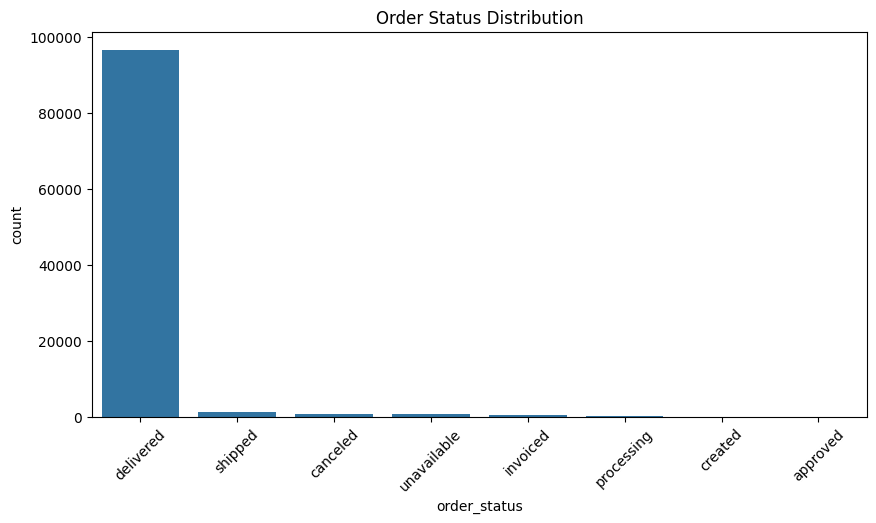

In [25]:
order_status_count = orders["order_status"].value_counts()
order_status_count

plt.figure(figsize=(10,5))
sns.countplot(
    data=orders,
    x="order_status",
    order=orders["order_status"].value_counts().index
)
plt.title("Order Status Distribution")
plt.xticks(rotation=45)
plt.show()

## Business KPI summary

In [26]:
total_orders = df["order_id"].nunique()
total_customers = df["customer_unique_id"].nunique()
total_revenue = df["total_payment_value"].sum()
average_order_value = df["total_payment_value"].mean()
average_review_score = df["review_score"].mean()

customer_order_count = df.groupby("customer_unique_id")["order_id"].nunique()
repeat_customers = customer_order_count[customer_order_count > 1].count()
repeat_customer_rate = (repeat_customers / total_customers) * 100

kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Delivered Orders",
        "Total Unique Customers",
        "Total Revenue",
        "Average Order Value",
        "Repeat Customer Rate (%)",
        "Average Review Score"
    ],
    "Value": [
        total_orders,
        total_customers,
        round(total_revenue, 2),
        round(average_order_value, 2),
        round(repeat_customer_rate, 2),
        round(average_review_score, 2)
    ]
})

kpi_summary



,Metric,Value
0,Total Delivered Orders,"96,478.00"
1,Total Unique Customers,"93,358.00"
2,Total Revenue,"15,422,605.23"
3,Average Order Value,159.86
4,Repeat Customer Rate (%),3.00
5,Average Review Score,4.16


# Acquisition Analysis

## Monthly revenue trend

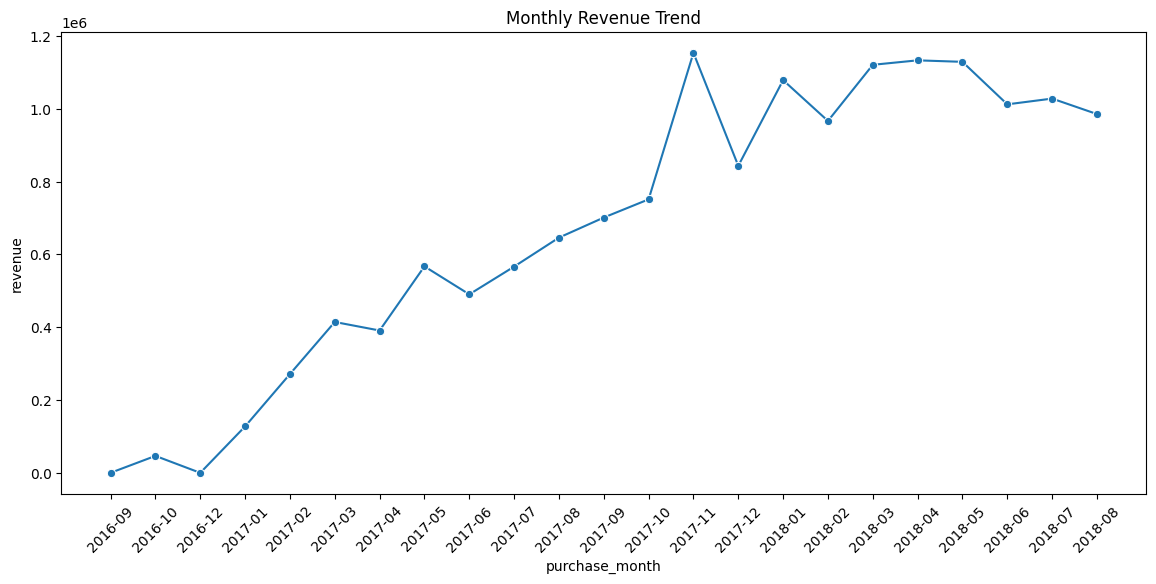

In [ ]:
monthly_revenue = df.groupby("purchase_month").agg(
    revenue=("total_payment_value", "sum"),
    orders=("order_id", "nunique"),
    customers=("customer_unique_id", "nunique")
).reset_index()

monthly_revenue.head()


plt.figure(figsize=(14,6))
sns.lineplot(data=monthly_revenue, x="purchase_month", y="revenue", marker="o")
plt.title("Monthly Revenue Trend")
plt.xticks(rotation=45)
plt.show()


## Monthly New vs Returning Customers

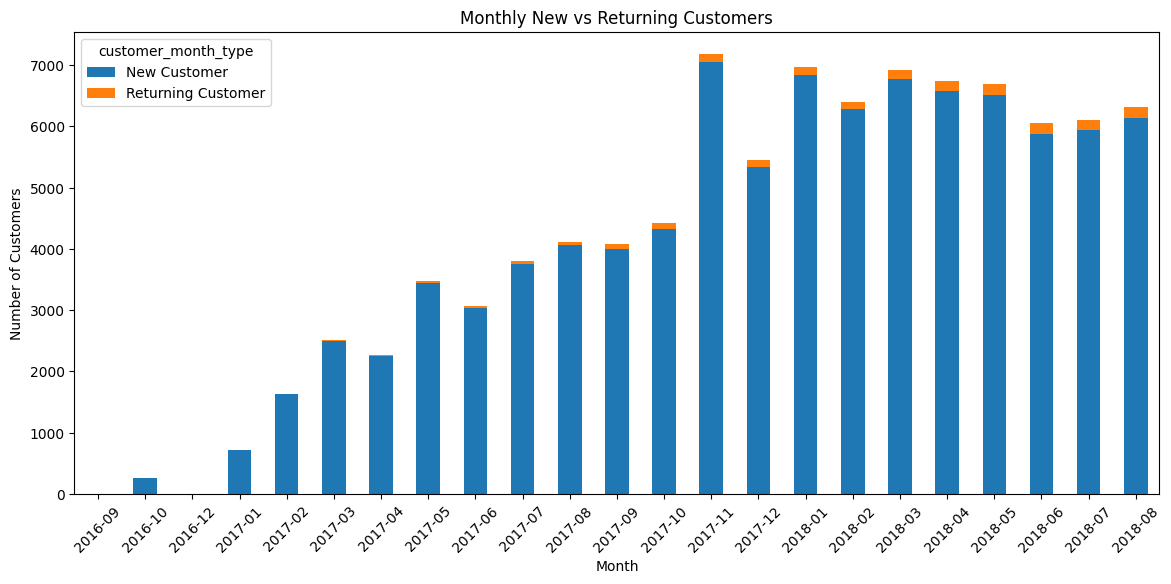

In [28]:
customer_first_purchase = df.groupby("customer_unique_id")["order_purchase_timestamp"].min().reset_index()

customer_first_purchase.columns = [
    "customer_unique_id",
    "first_purchase_date"
]

customer_first_purchase["first_purchase_month"] = (
    customer_first_purchase["first_purchase_date"]
    .dt.to_period("M")
    .astype(str)
)

df_customer_type = df.merge(
    customer_first_purchase[["customer_unique_id", "first_purchase_month"]],
    on="customer_unique_id",
    how="left"
)

df_customer_type["customer_month_type"] = np.where(
    df_customer_type["purchase_month"] == df_customer_type["first_purchase_month"],
    "New Customer",
    "Returning Customer"
)

monthly_customer_type = (
    df_customer_type
    .drop_duplicates(["purchase_month", "customer_unique_id"])
    .groupby(["purchase_month", "customer_month_type"])
    .agg(customers=("customer_unique_id", "nunique"))
    .reset_index()
)

monthly_customer_pivot = monthly_customer_type.pivot(
    index="purchase_month",
    columns="customer_month_type",
    values="customers"
).fillna(0)

monthly_customer_pivot = monthly_customer_pivot.reset_index()

monthly_customer_pivot.head()

monthly_customer_pivot.plot(
    x="purchase_month",
    kind="bar",
    stacked=True,
    figsize=(14, 6)
)

plt.title("Monthly New vs Returning Customers")
plt.xlabel("Month")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

## One-time vs Repeat Customers

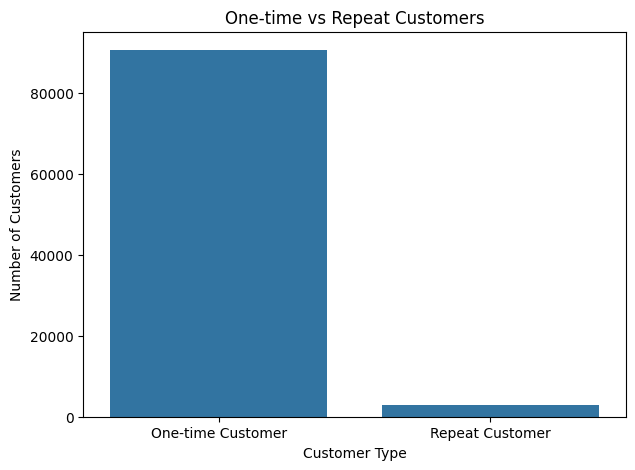

In [29]:
customer_summary = df.groupby("customer_unique_id").agg(
    total_orders=("order_id", "nunique"),
    total_spent=("total_payment_value", "sum"),
    avg_order_value=("total_payment_value", "mean"),
    first_purchase=("order_purchase_timestamp", "min"),
    last_purchase=("order_purchase_timestamp", "max")
).reset_index()

customer_summary["customer_type"] = np.where(
    customer_summary["total_orders"] > 1,
    "Repeat Customer",
    "One-time Customer"
)

customer_summary.head()
customer_type_count = customer_summary["customer_type"].value_counts().reset_index()
customer_type_count.columns = ["customer_type", "customers"]

customer_type_count


plt.figure(figsize=(7, 5))

sns.barplot(
    data=customer_type_count,
    x="customer_type",
    y="customers"
)

plt.title("One-time vs Repeat Customers")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")
plt.show()

In [30]:
customer_type_revenue = customer_summary.groupby("customer_type").agg(
    customers=("customer_unique_id", "nunique"),
    total_revenue=("total_spent", "sum"),
    avg_customer_spend=("total_spent", "mean"),
    avg_orders_per_customer=("total_orders", "mean")
).reset_index()

customer_type_revenue["revenue_share_%"] = (
    customer_type_revenue["total_revenue"] / customer_type_revenue["total_revenue"].sum()
) * 100

customer_type_revenue

,customer_type,customers,total_revenue,avg_customer_spend,avg_orders_per_customer,revenue_share_%
0,One-time Customer,90557,"14,558,248.02",160.76,1.00,94.40
1,Repeat Customer,2801,"864,357.21",308.59,2.11,5.60


## RFM Customer Segmentation

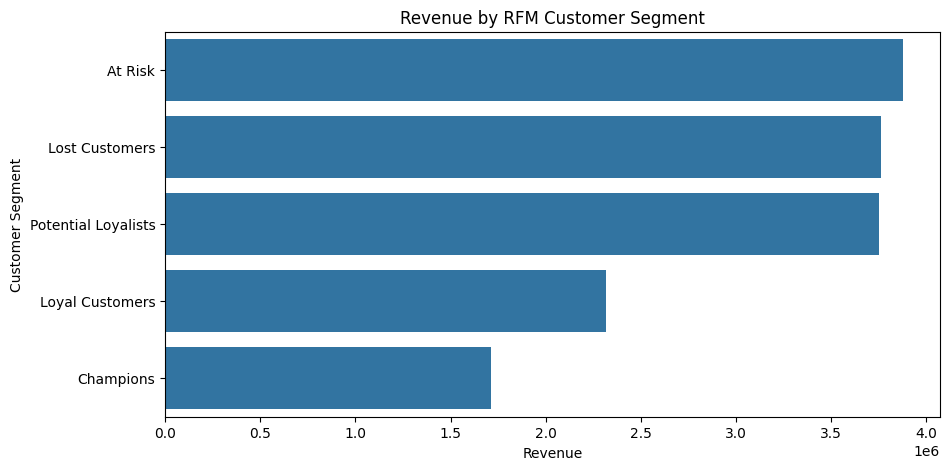

In [31]:
snapshot_date = df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm = df.groupby("customer_unique_id").agg(
    recency=("order_purchase_timestamp", lambda x: (snapshot_date - x.max()).days),
    frequency=("order_id", "nunique"),
    monetary=("total_payment_value", "sum")
).reset_index()

rfm.head()

rfm["R_score"] = pd.qcut(
    rfm["recency"].rank(method="first"),
    4,
    labels=[4, 3, 2, 1]
)

rfm["F_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
)

rfm["M_score"] = pd.qcut(
    rfm["monetary"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
)

rfm["R_score_num"] = rfm["R_score"].astype(int)
rfm["F_score_num"] = rfm["F_score"].astype(int)
rfm["M_score_num"] = rfm["M_score"].astype(int)

rfm["RFM_score"] = (
    rfm["R_score"].astype(str) +
    rfm["F_score"].astype(str) +
    rfm["M_score"].astype(str)
)

rfm.head()

def segment_customer(row):
    if row["R_score_num"] >= 4 and row["F_score_num"] >= 3 and row["M_score_num"] >= 3:
        return "Champions"
    elif row["R_score_num"] >= 3 and row["F_score_num"] >= 3:
        return "Loyal Customers"
    elif row["R_score_num"] >= 3 and row["F_score_num"] <= 2:
        return "Potential Loyalists"
    elif row["R_score_num"] <= 2 and row["F_score_num"] >= 3:
        return "At Risk"
    elif row["R_score_num"] <= 2 and row["F_score_num"] <= 2:
        return "Lost Customers"
    else:
        return "Others"

rfm["segment"] = rfm.apply(segment_customer, axis=1)

rfm.head()

segment_summary = rfm.groupby("segment").agg(
    customers=("customer_unique_id", "nunique"),
    avg_recency=("recency", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean"),
    total_revenue=("monetary", "sum")
).reset_index().sort_values("total_revenue", ascending=False)

segment_summary["revenue_share_%"] = (
    segment_summary["total_revenue"] / segment_summary["total_revenue"].sum()
) * 100

segment_summary

plt.figure(figsize=(10, 5))

sns.barplot(
    data=segment_summary,
    y="segment",
    x="total_revenue"
)

plt.title("Revenue by RFM Customer Segment")
plt.xlabel("Revenue")
plt.ylabel("Customer Segment")
plt.show()




## Top States by Revenue

In [47]:
state_summary = df.groupby("customer_state").agg(
    customers=("customer_unique_id", "nunique"),
    orders=("order_id", "nunique"),
    revenue=("total_payment_value", "sum"),
    avg_order_value=("total_payment_value", "mean")
).reset_index().sort_values("revenue", ascending=False)

state_summary.head(10)

,customer_state,customers,orders,revenue,avg_order_value
25,SP,39156,40501,"5,770,409.65",142.48
18,RJ,11917,12350,"2,055,690.45",166.45
10,MG,11001,11354,"1,819,277.61",160.23
22,RS,5168,5345,"861,802.40",161.24
17,PR,4769,4923,"781,919.55",158.83
23,SC,3449,3546,"595,208.40",167.85
4,BA,3158,3256,"591,270.60",181.59
6,DF,2019,2080,"346,146.17",166.42
8,GO,1895,1957,"334,294.22",170.82
7,ES,1928,1995,"317,682.65",159.24


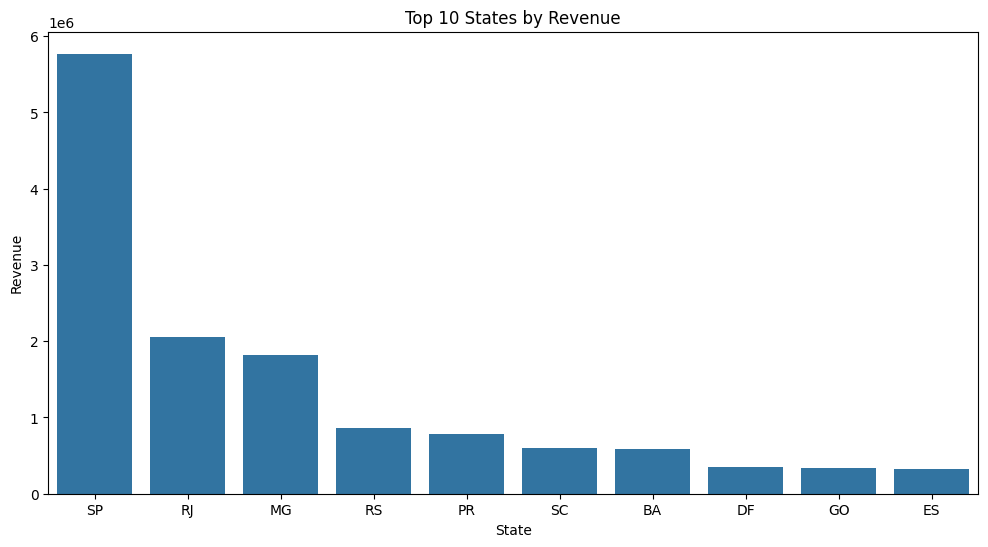

In [33]:

plt.figure(figsize=(12, 6))

sns.barplot(
    data=state_summary.head(10),
    x="customer_state",
    y="revenue"
)

plt.title("Top 10 States by Revenue")
plt.xlabel("State")
plt.ylabel("Revenue")
plt.show()


## Top Product Categories by Revenue

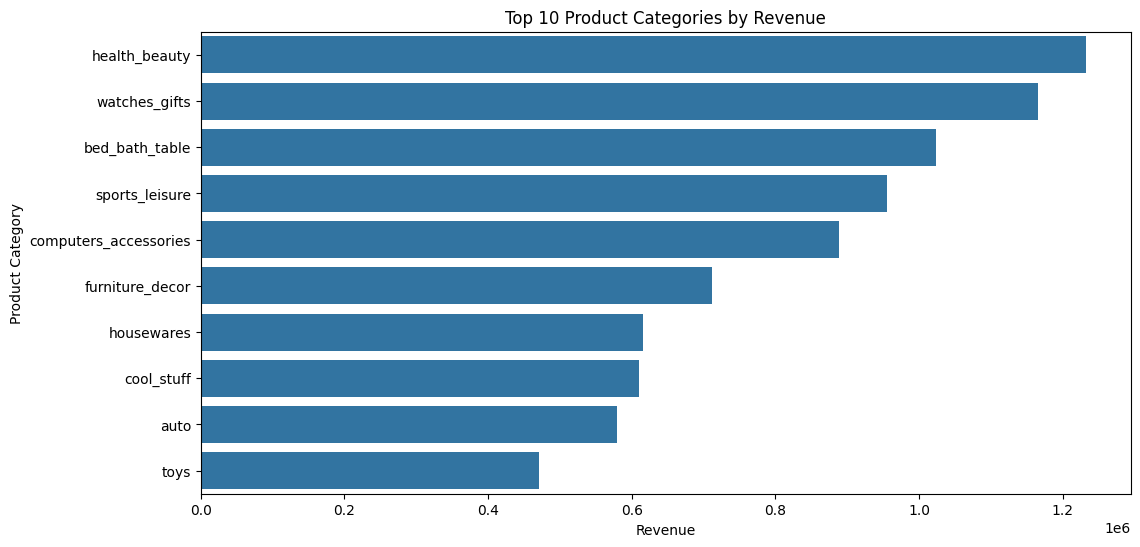

In [34]:
items_products = items.merge(
    products,
    on="product_id",
    how="left"
)

items_products = items_products.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

items_products["product_category_name_english"] = (
    items_products["product_category_name_english"].fillna("unknown")
)

category_df = items_products.merge(
    delivered_orders[["order_id", "order_purchase_timestamp"]],
    on="order_id",
    how="inner"
)

category_summary = category_df.groupby("product_category_name_english").agg(
    orders=("order_id", "nunique"),
    items_sold=("order_item_id", "count"),
    revenue=("price", "sum"),
    freight=("freight_value", "sum")
).reset_index().sort_values("revenue", ascending=False)

category_summary.head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=category_summary.head(10),
    y="product_category_name_english",
    x="revenue"
)

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product Category")
plt.show()

## Delivery Delay vs Review Score

In [35]:
delivery_df = df.dropna(
    subset=["order_delivered_customer_date", "order_estimated_delivery_date"]
).copy()

delivery_df["delivery_days"] = (
    delivery_df["order_delivered_customer_date"] -
    delivery_df["order_purchase_timestamp"]
).dt.days

delivery_df["delivery_delay_days"] = (
    delivery_df["order_delivered_customer_date"] -
    delivery_df["order_estimated_delivery_date"]
).dt.days

delivery_df["delivery_status"] = np.where(
    delivery_df["delivery_delay_days"] > 0,
    "Late Delivery",
    "On-time / Early Delivery"
)

delivery_review_summary = delivery_df.groupby("delivery_status").agg(
    orders=("order_id", "nunique"),
    avg_review_score=("review_score", "mean"),
    avg_delivery_days=("delivery_days", "mean"),
    avg_delay_days=("delivery_delay_days", "mean")
).reset_index()

delivery_review_summary

,delivery_status,orders,avg_review_score,avg_delivery_days,avg_delay_days
0,Late Delivery,6534,2.34,33.49,10.62
1,On-time / Early Delivery,89936,4.29,10.54,-13.51


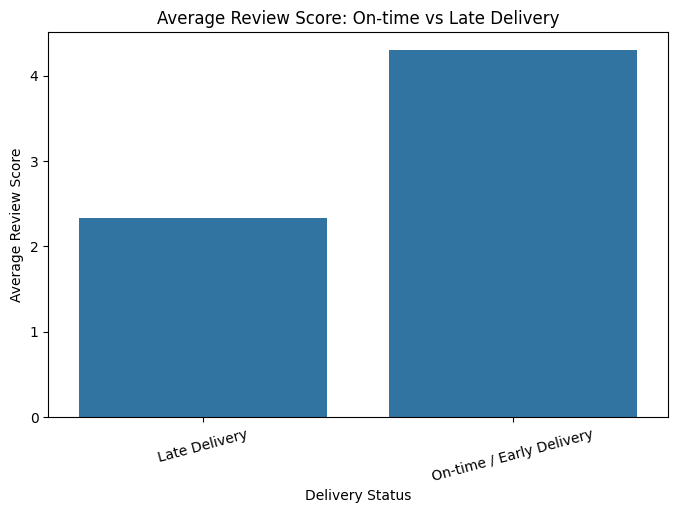

In [36]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=delivery_review_summary,
    x="delivery_status",
    y="avg_review_score"
)

plt.title("Average Review Score: On-time vs Late Delivery")
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")
plt.xticks(rotation=15)
plt.show()


In [37]:
total_delivery_orders = delivery_df["order_id"].nunique()

late_delivery_orders = delivery_df[
    delivery_df["delivery_delay_days"] > 0
]["order_id"].nunique()

late_delivery_rate = (late_delivery_orders / total_delivery_orders) * 100

print("Total Delivered Orders with Delivery Date:", total_delivery_orders)
print("Late Delivery Orders:", late_delivery_orders)
print("Late Delivery Rate:", round(late_delivery_rate, 2), "%")

Total Delivered Orders with Delivery Date: 96470
Late Delivery Orders: 6534
Late Delivery Rate: 6.77 %


## Key Insight: Olist has strong customer acquisition and revenue volume, but the business is highly dependent on first-time buyers.
### * The platform generated strong sales from 96K+ delivered orders and 93K+ unique customers, showing that it is successful at attracting customers.
### * The repeat customer rate is very low at around 3%, which means most customers purchase only once.
### * Revenue growth is mainly driven by new customer acquisition rather than repeat purchases from existing customers.
### * This creates a major opportunity to improve customer lifetime value through lifecycle marketing and retention strategies.
### * Recommended actions include personalized recommendations, win-back campaigns, loyalty offers, cross-sell campaigns, and better delivery experience to encourage repeat purchases.

In [38]:
 print("\n" + "="*100)

## Hypothesis 1: Late delivery reduces review score

In [39]:
from scipy.stats import mannwhitneyu

delivery_test_df = df.dropna(subset=["delivery_delay_days", "review_score"]).copy()

late_reviews = delivery_test_df[delivery_test_df["delivery_delay_days"] > 0]["review_score"]
ontime_reviews = delivery_test_df[delivery_test_df["delivery_delay_days"] <= 0]["review_score"]

stat, p_value = mannwhitneyu(
    late_reviews,
    ontime_reviews,
    alternative="two-sided"
)

print("Average review score - Late delivery:", round(late_reviews.mean(), 2))
print("Average review score - On-time/Early delivery:", round(ontime_reviews.mean(), 2))
print("P-value:", p_value)

if p_value < 0.05:
    print("Result: Significant difference. Delivery delay is associated with review score.")
else:
    print("Result: No significant difference found.")

Average review score - Late delivery: 2.34
Average review score - On-time/Early delivery: 4.29
P-value: 0.0
Result: Significant difference. Delivery delay is associated with review score.


### Hypothesis: Late deliveries receive lower customer review scores than on-time or early deliveries.
### Test used: Mann-Whitney U test.
### Reason: Review scores are ordinal ratings from 1 to 5, so a non-parametric test is safer than assuming normal distribution.
### Conclusion: The p-value is below 0.05, late delivery has a statistically significant relationship with lower review scores.

In [40]:
 print("\n" + "="*100)

## Hypothesis 2: Are repeat customers associated with higher spending segments?

In [41]:
from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

customer_summary = df.groupby("customer_unique_id").agg(
    total_orders=("order_id", "nunique"),
    total_spent=("total_payment_value", "sum"),
    avg_order_value=("total_payment_value", "mean")
).reset_index()

customer_summary["customer_type"] = np.where(
    customer_summary["total_orders"] > 1,
    "Repeat Customer",
    "One-time Customer"
)

median_spend = customer_summary["total_spent"].median()

customer_summary["spending_segment"] = np.where(
    customer_summary["total_spent"] >= median_spend,
    "High Spend Customer",
    "Low Spend Customer"
)


customer_spend_table = pd.crosstab(
    customer_summary["customer_type"],
    customer_summary["spending_segment"]
)

customer_spend_table

spending_segment,High Spend Customer,Low Spend Customer
customer_type,,
One-time Customer,44316,46241
Repeat Customer,2467,334


In [42]:
chi2, p_value, dof, expected = chi2_contingency(customer_spend_table)

print("Chi-square statistic:", chi2)
print("P-value:", p_value)
print("Degrees of freedom:", dof)

if p_value < 0.05:
    print("Result: Reject H0. Customer type and spending segment are significantly associated.")
else:
    print("Result: Fail to reject H0. No significant association found.")

Chi-square statistic: 1663.2088393717859
P-value: 0.0
Degrees of freedom: 1
Result: Reject H0. Customer type and spending segment are significantly associated.


In [43]:
customer_spend_percentage = pd.crosstab(
    customer_summary["customer_type"],
    customer_summary["spending_segment"],
    normalize="index"
) * 100

customer_spend_percentage.round(2)

spending_segment,High Spend Customer,Low Spend Customer
customer_type,,
One-time Customer,48.94,51.06
Repeat Customer,88.08,11.92


### Hypothesis: Are repeat customers associated with higher spending segments?
### Test used: Chi-square Test.
### Reason:  Both variables are categorical. Customer type includes One-time Customer and Repeat Customer, while spending segment includes High Spend Customer and Low Spend Customer.
###          The Chi-square test checks whether these two categorical variables are statistically associated.
### Conclusion: The p-value is below 0.05, customer type and spending segment are significantly associated.

In [44]:
 print("\n" + "="*100)

# Actionables:

### Since the repeat customer rate is only around 3%, Olist should focus on post-purchase lifecycle campaigns. This can include second-purchase coupons, personalized recommendations, cross-sell campaigns, loyalty offers, and win-back campaigns. The goal is to reduce dependency on new customer acquisition and increase customer lifetime value.
### The delivery analysis shows that late deliveries are linked with lower customer review scores. Olist should monitor late-risk orders, improve delivery communication, track seller/logistics performance, and prioritize regions or sellers with repeated delivery delays. Improving delivery experience can help increase satisfaction and improve the chance of repeat purchase.

## Further exploration question: Why are most customers not making a second purchase?

### This needs further analysis because the current dataset shows that repeat purchase behavior is weak, but it does not fully explain the reason behind it. Additional data such as marketing campaign exposure, discount usage, browsing behavior, customer support tickets, and abandoned cart activity would help identify whether the issue is caused by poor remarketing, product fit, price sensitivity, delivery experience, or lack of loyalty incentives.

In [45]:
df.to_csv("olist_cleaned_order_level_data.csv", index=False)

kpi_summary.to_csv("kpi_summary.csv", index=False)
monthly_revenue.to_csv("monthly_revenue.csv", index=False)
monthly_customer_pivot.to_csv("monthly_new_vs_returning_customers.csv", index=False)
customer_summary.to_csv("customer_summary.csv", index=False)
customer_type_revenue.to_csv("customer_type_revenue.csv", index=False)
rfm.to_csv("rfm_customer_segments.csv", index=False)
segment_summary.to_csv("segment_summary.csv", index=False)
state_summary.to_csv("state_summary.csv", index=False)
category_summary.to_csv("category_summary.csv", index=False)
delivery_review_summary.to_csv("delivery_review_summary.csv", index=False)

print("All Power BI files exported successfully.")

All Power BI files exported successfully.
